In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections.abc import Mapping
from IPython.display import display
from plotting_utils import create_df_runs, apply_presentation_theme
from matplotlib.container import BarContainer
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
import numpy as np

In [36]:
#df_runs = create_df_runs()
df_runs = create_df_runs(hypothesis_to_filter="structured_spec_conversational_reruns")

df_runs created and its head looks like this:


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,18,19,2026-06-02T12:22:25.400514__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,36223bca,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
1,25,26,2026-06-02T16:12:53.291662__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,4bdd97f2,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
2,81,82,2026-06-02T14:10:19.298501__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,a285b287,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...


Configurations found and their run counts:


,Count
config_key,
"(claude-sonnet-4-5, StructuredSpecification-ChildBenefit-v2.md, False)",3


In [37]:
df_runs.columns

Index(['level_0', 'index', 'run_name', 'model', 'prompt', 'url_allowed',
       'commit', 'hypothesis_name', 'results', 'prompt_name', 'prompt_type',
       'model_name', 'config_key', 'prompt_version', 'config_label'],
      dtype='object')

In [38]:
def build_case_category_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    expected = []
    actual = []

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            #if case_id not in expected:
            #    expected[case_id] = {}
            #if case_id not in actual:
            #    actual[case_id] = {}
            #records[case_id][run_name] = case_data.get("child_evaluations", [])
            #records[case_id][run_name] = [(child["expected_eligible"], child["actual_eligible"]) for child in case_data.get("child_evaluations", []).values()]

            #actual[case_id][run_name] = [child["actual_eligible"] for child in case_data.get("child_evaluations", []).values()]
            #expected[case_id][run_name] = [child["expected_eligible"] for child in case_data.get("child_evaluations", []).values()]

            actual.extend([[case_id, run_name, child_name, child.get("actual_eligible")] for child_name, child in case_data.get("child_evaluations", []).items()])
            expected.extend([[case_id, run_name, child_name, child.get("expected_eligible")] for child_name, child in case_data.get("child_evaluations", []).items()])

    #df_matrix = pd.DataFrame.from_dict(records, orient="index")
    actual_df = pd.DataFrame.from_records(
        actual, 
        columns=["CaseId", "RunName", "ChildName", "Eligibility"],
        index=["CaseId", "RunName", "ChildName"],
    )
    expected_df = pd.DataFrame.from_records(
        expected, 
        columns=["CaseId", "RunName", "ChildName", "Eligibility"],
        index=["CaseId", "RunName", "ChildName"],
    )
    # See "analysis/testOutputs/child_benefit/2026-05-18T12:14:53.570138__Model=claude-sonnet-4-5__Commit=759efcde/concatenated_test_uncertainty_cases/Permutation_RND_SET_2_014.conversation.json"
    # for an example of where for some reason the agent has used the value of the enumeration rather than the key
    actual_df["Eligibility"] = actual_df["Eligibility"][actual_df["Eligibility"].isin(["ELIGIBLE", "INELIGIBLE", "INDETERMINATE"])]
    expected_df["Eligibility"] = expected_df["Eligibility"][actual_df["Eligibility"].isin(["ELIGIBLE", "INELIGIBLE", "INDETERMINATE"])]

    
    actual_df["Eligibility"] = actual_df["Eligibility"].astype("category")
    expected_df["Eligibility"] = expected_df["Eligibility"].astype("category")

    return actual_df, expected_df


In [39]:
df_runs


,level_0,index,run_name,model,prompt,url_allowed,commit,hypothesis_name,results,prompt_name,prompt_type,model_name,config_key,prompt_version,config_label
0,18,19,2026-06-02T12:22:25.400514__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,36223bca,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
1,25,26,2026-06-02T16:12:53.291662__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,4bdd97f2,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...
2,81,82,2026-06-02T14:10:19.298501__Model=claude-sonne...,eu.anthropic.claude-sonnet-4-5-20250929-v1:0,agents/TechnicalHypotheses/StructuredSpecifica...,False,a285b287,structured_spec_conversational_reruns,{'APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_0...,StructuredSpecification-ChildBenefit-v2.md,Structured spec with indeterminacy,claude-sonnet-4-5,"(claude-sonnet-4-5, StructuredSpecification-Ch...",v2,claude-sonnet-4-5 | Structured spec with indet...


In [40]:
actual, expected = build_case_category_matrix(df_runs)


In [41]:
actual["Eligibility"].value_counts()

Eligibility
INELIGIBLE       350
ELIGIBLE         341
INDETERMINATE    179
Name: count, dtype: int64

In [42]:
expected["Eligibility"].value_counts()

Eligibility
INDETERMINATE    324
INELIGIBLE       275
ELIGIBLE         271
Name: count, dtype: int64

In [43]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
le_actual = le.fit_transform(actual.dropna())
le_expected = le.fit_transform(expected.dropna())

/System/Volumes/Data/Users/toby.petty/Src/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/System/Volumes/Data/Users/toby.petty/Src/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [44]:
le.classes_

array(['ELIGIBLE', 'INDETERMINATE', 'INELIGIBLE'], dtype=object)

Text(0.5, 1.0, 'Confusion Matrix describing children associated with all runs')

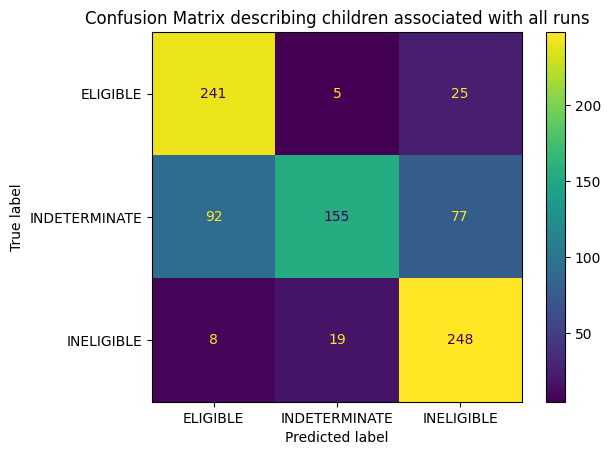

In [45]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_true=le_expected, 
    y_pred=le_actual,
)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
plt.title("Confusion Matrix describing children associated with all runs")


# What are the results?

* The numbers you see represent per-child eligilbity assessments made over 6 full test runs, each containing 199 test cases 
  * Each of the test cases we have generated describes one or more children in a family
  * It is possible for one child in a family to be eligible for child benefit but another child ineligble for child benefit
* The vertical axis represents the response the agent should have given
* The horizonal axis represents the response the agent actually gave
* `INDETERMINATE` is another way of saying that the answer can't be determined
* Any answers in the top-left to bottom-right diagonal (i.e. the ones with 524, 316, 443) are correct answers
  * This is because this is where the response the agent should have given and the response it gave are the same

## What do these tell us?

* The most common failure mode is where the response the agent should have given was "I don't know" i.e `INDETERMINATE`, but actually the agent gave the response of "this child is eligible"
    * We've discussed before that of all the failure modes, this one is most preferable as the outcome is that the person will try to claim child benefit and be denied
    * This is better than someone being told their not eligible for child benefit, when in fact they might be.

In [46]:
def build_case_reliability_matrix(target_runs: pd.DataFrame) -> pd.DataFrame:
    """
    Build a pass/fail matrix for one configuration across multiple runs.

    Rows = case IDs
    Columns = run names
    Values = boolean pass/fail
    """
    records: dict[str, dict[str, bool]] = {}

    for row in target_runs.itertuples(index=False):
        run_name = row.run_name
        results = row.results

        if not isinstance(results, Mapping):
            continue

        for case_id, case_data in results.items():
            if case_id == "run_config":
                continue

            if case_id not in records:
                records[case_id] = {}

            records[case_id][run_name] = case_data.get("overall_is_correct", False)

    df_matrix = pd.DataFrame.from_dict(records, orient="index")

    df_matrix["Pass_Rate"] = df_matrix.mean(axis=1)

    df_matrix["Category"] = pd.cut(
        df_matrix["Pass_Rate"],
        bins=[-0.1, 0.0, 0.99, 1.0],
        labels=["Systematic Fail", "Flaky", "Always Passes"],
    )

    return df_matrix


def build_reliability_matrices_by_config(
    df_runs: pd.DataFrame,
    min_runs: int = 3,
) -> dict[str, pd.DataFrame]:
    """
    Build one reliability matrix per configuration, keeping only configurations
    with at least `min_runs` runs.
    """
    # Group by the clean config_label instead of the tuple
    config_counts = df_runs["config_label"].value_counts()
    eligible_config_labels = config_counts[config_counts >= min_runs].index.tolist()

    matrices = {}

    for config_label in eligible_config_labels:
        target_runs = df_runs.loc[df_runs["config_label"] == config_label]
        matrices[config_label] = build_case_reliability_matrix(target_runs)

    return matrices

In [47]:
reliability_matrices = build_reliability_matrices_by_config(df_runs, min_runs=1)

for config_key, df_matrix in reliability_matrices.items():
    print(f"\n=== Reliability Summary: {config_key} ===")
    display(df_matrix["Category"].value_counts().to_frame("Number of Cases"))

    hard_cases = df_matrix[df_matrix["Pass_Rate"] < 1.0].sort_values("Pass_Rate")
    if not hard_cases.empty:
        print("\n🚨 Examples of flaky and Failing Cases:")
        display(hard_cases[["Pass_Rate", "Category"]].head(10))


=== Reliability Summary: claude-sonnet-4-5 | Structured spec with indeterminacy ===


,Number of Cases
Category,
Always Passes,102
Flaky,51
Systematic Fail,46



🚨 Examples of flaky and Failing Cases:


,Pass_Rate,Category
APPRENTICESHIP_LOCATION_INDET_SCOTLAND_RND_013,0.0,Systematic Fail
APPRENTICESHIP_LOCATION_INDET_WALES_RND_072,0.0,Systematic Fail
APPRENTICESHIP_INDET_STATUS_UNKNOWN_RND_050,0.0,Systematic Fail
APPRENTICESHIP_LOCATION_INDET_NORTHERN_IRELAND,0.0,Systematic Fail
ADOPTION_INDET_BEFORE_CHILD_MOVES_IN,0.0,Systematic Fail
RESPONSIBILITY_INDET_PRIORITY_UNKNOWN,0.0,Systematic Fail
PRE_SETTLED_STATUS_INDET_FINANCIAL_RESOURCES_UNKNOWN_RND_040,0.0,Systematic Fail
INFORMAL_ARRANGEMENT_INDET_BASIC_RND_036,0.0,Systematic Fail
INFORMAL_ARRANGEMENT_INDET_BASIC_RND_076,0.0,Systematic Fail
ADOPTION_INDET_BEFORE_CHILD_MOVES_IN_RND_018,0.0,Systematic Fail


/System/Volumes/Data/Users/toby.petty/Src/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/System/Volumes/Data/Users/toby.petty/Src/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Text(0.5, 1.0, 'Confusion Matrix describing describing children associated with cases which have no successful runs')

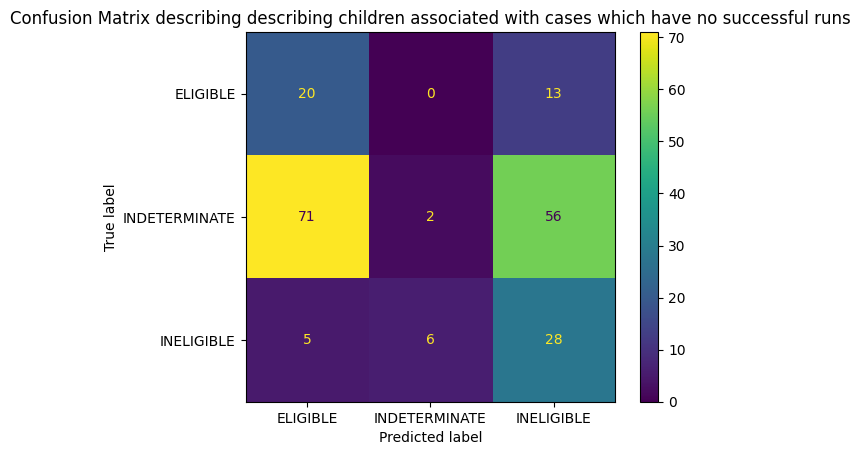

In [48]:
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
le = LabelEncoder()
cm = confusion_matrix(
    y_true=le.fit_transform(
        expected
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Systematic Fail"
            ].index
        ]
    ),
    y_pred=le.fit_transform(
        actual
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Systematic Fail"
            ].index
        ]
    ),
)
#print(le.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
plt.title("Confusion Matrix describing describing children associated with cases which have no successful runs")



## What are the results?

* The numbers you see represent per-child eligilbity assessments made over 6 full test runs, for only those test cases that had at least one child fail on each of the 6 runs
  * Each of the test cases we have generated describes one or more children in a family
  * It is possible for one child in a family to be eligible for child benefit but another child ineligble for child benefit
* The vertical axis represents the response the agent should have given
* The horizonal axis represents the response the agent actually gave
* `INDETERMINATE` is another way of saying that the answer can't be determined
* Any answers in the top-left to bottom-right diagonal (i.e. the ones with 524, 316, 443) are correct answers
  * This is because this is where the response the agent should have given and the response it gave are the same

## What do these tell us?

* As with the results above, we see the most common failure mode is where the response the agent should have given was "I don't know" i.e `INDETERMINATE`, but actually the agent gave the response of "this child is eligible"
    * But the number of per-child eligilbity responses failing into this failure mode represents the majority of results here

['ELIGIBLE' 'INDETERMINATE' 'INELIGIBLE']


/System/Volumes/Data/Users/toby.petty/Src/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/System/Volumes/Data/Users/toby.petty/Src/gds-eligibility-agentic-backend/analysis/.venv/lib/python3.14/site-packages/sklearn/preprocessing/_label.py:120: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Text(0.5, 1.0, 'Confusion Matrix describing children associated with cases which sometimes pass & sometimes fail')

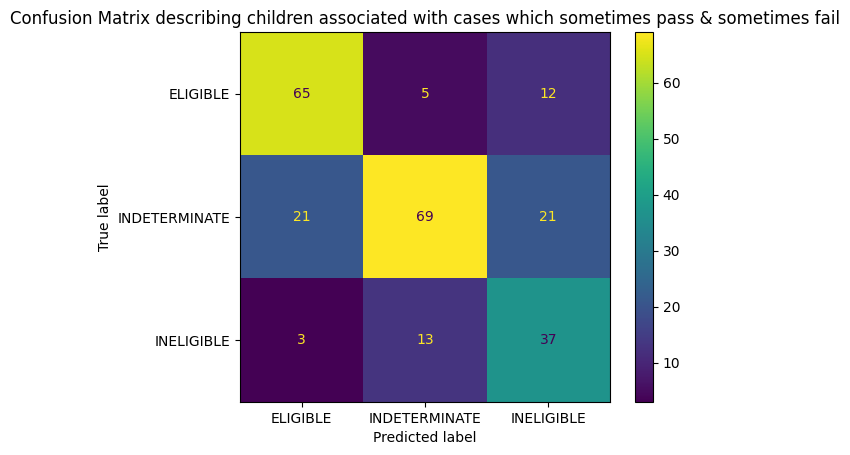

In [49]:
#from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#le = LabelEncoder()
cm = confusion_matrix(
    y_true=le.fit_transform(
        expected
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Flaky"
            ].index
        ]
    ),
    y_pred=le.fit_transform(
        actual
        .dropna()
        .droplevel(1)
        .droplevel(1)
        .loc[
            hard_cases[
                hard_cases["Category"] == "Flaky"
            ].index
        ]
    ),
)
print(le.classes_)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)
disp.plot()
plt.title("Confusion Matrix describing children associated with cases which sometimes pass & sometimes fail")


## What are the results?

* The numbers you see represent per-child eligilbity assessments made over 6 full test runs, for only those test cases that had at least one child fail on at least one run, and succeed in at least one run
  * Each of the test cases we have generated describes one or more children in a family
  * It is possible for one child in a family to be eligible for child benefit but another child ineligble for child benefit
* The vertical axis represents the response the agent should have given
* The horizonal axis represents the response the agent actually gave
* `INDETERMINATE` is another way of saying that the answer can't be determined
* Any answers in the top-left to bottom-right diagonal (i.e. the ones with 524, 316, 443) are correct answers
  * This is because this is where the response the agent should have given and the response it gave are the same

## What do these tell us?

* As with the results above, we see the most common failure mode is where the response the agent should have given was "I don't know" i.e `INDETERMINATE`, but actually the agent gave the response of "this child is eligible"
    * But ehislt they are the most common failure mode, there are a mixture of other failure modes present

# Next Steps

* Further analysis to identify any further commonalities amongst failiure modes that might help us iterate
* Control for "actor hallucination" by adding further runs using the "facts-bundle" approach i.e. without an actor agent
* Investigate the effect of providing the rules in a structured manner, by adding further runs using the structured rules approach

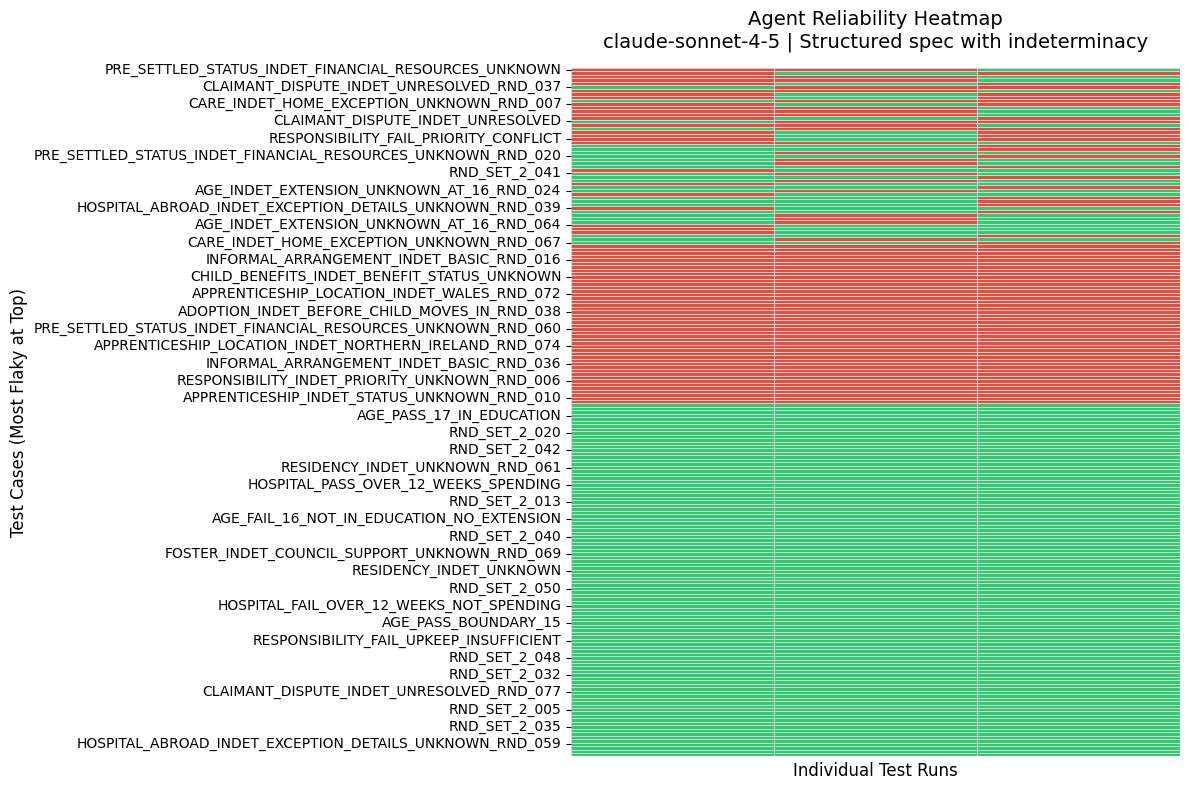

In [50]:
def plot_reliability_heatmaps(
    reliability_matrices: dict[str, pd.DataFrame],
) -> None:
    """
    Plot a reliability heatmap for each configuration.
    Sorted by variance (flakiness) so unreliable cases sit at the top.
    """
    cmap = sns.color_palette(["#e74c3c", "#2ecc71"])

    # Dictionary key is now just the string label
    for config_label, df_matrix in reliability_matrices.items():
        run_cols = [c for c in df_matrix.columns if c not in ["Pass_Rate", "Category"]]
        df_matrix["Flakiness"] = df_matrix[run_cols].var(axis=1)
        df_sorted = df_matrix.sort_values(
            by=["Flakiness", "Pass_Rate"], ascending=[False, True]
        )

        heatmap_data = df_sorted[run_cols].astype(float)

        if heatmap_data.empty:
            continue

        plt.figure(figsize=(12, 8))

        sns.heatmap(
            heatmap_data,
            cmap=cmap,
            cbar=False,
            linewidths=0.5,
            linecolor="lightgray",
            xticklabels=False,
        )

        # Use the config_label directly in the title
        plt.title(
            f"Agent Reliability Heatmap\n{config_label}",
            fontsize=14,
            pad=15,
        )

        plt.xlabel("Individual Test Runs", fontsize=12)
        plt.ylabel("Test Cases (Most Flaky at Top)", fontsize=12)

        plt.tight_layout()
        plt.show()


plot_reliability_heatmaps(reliability_matrices)

In [51]:
def plot_comparative_reliability(reliability_matrices: dict[str, pd.DataFrame]) -> None:
    """
    Creates a 100% stacked bar chart comparing the reliability
    and accuracy of different agent configurations.
    """
    records = []

    for config_label, df_matrix in reliability_matrices.items():
        # Calculate the percentage of cases in each category
        category_percentages = df_matrix["Category"].value_counts(normalize=True) * 100

        records.append(
            {
                "Configuration": config_label,  # Mapped directly!
                "Always Passes": category_percentages.get("Always Passes", 0),
                "Systematic Fail": category_percentages.get("Systematic Fail", 0),
                "Flaky (Non-Deterministic)": category_percentages.get("Flaky", 0),
            }
        )

    df_plot = pd.DataFrame(records).set_index("Configuration")

    # Sort the dataframe so the most reliable configs (lowest Flaky rate) are at the top
    df_plot = df_plot.sort_values(by="Flaky (Non-Deterministic)", ascending=True)

    # Plotting
    colors = ["#2ecc71", "#e74c3c", "#f1c40f"]  # Green, Red, Yellow

    ax = df_plot[
        ["Always Passes", "Systematic Fail", "Flaky (Non-Deterministic)"]
    ].plot(
        kind="barh",
        stacked=True,
        figsize=(12, max(4, len(df_plot) * 1.2)),
        color=colors,
        width=0.7,
    )

    plt.title("Configuration Comparison: Reliability vs. Accuracy", fontsize=16, pad=20)
    plt.xlabel("Percentage of Test Cases (%)", fontsize=12)
    plt.ylabel("")

    ax.xaxis.set_major_formatter(mtick.PercentFormatter())
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

    for container in ax.containers:
        for p in container:
            width = p.get_width()
            if width > 3:
                ax.annotate(
                    f"{width:.1f}%",
                    (p.get_x() + width / 2, p.get_y() + p.get_height() / 2),
                    ha="center",
                    va="center",
                    color="black",
                    fontsize=10,
                    fontweight="bold",
                )

    plt.tight_layout()
    plt.show()

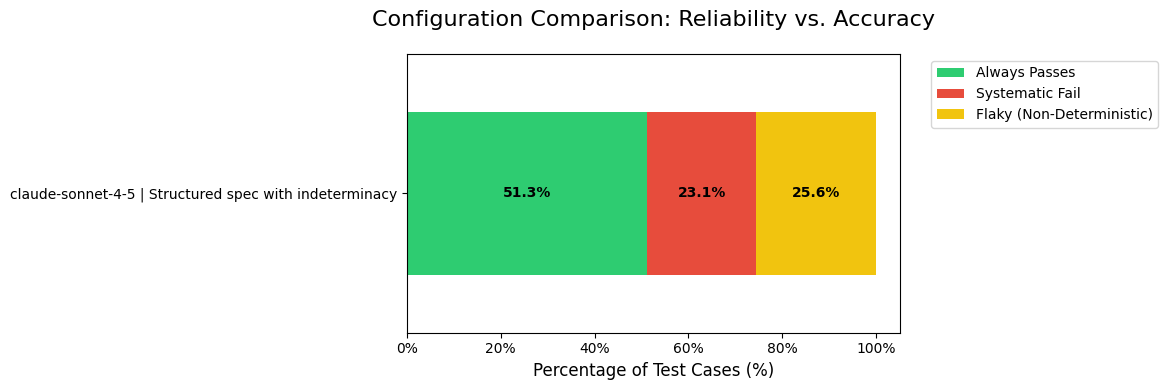

In [52]:
plot_comparative_reliability(reliability_matrices)